# Third-Party Breach News Classification — SLM Fine-Tuning Benchmark

**3**-Class Classification | LoRA/QLoRA | 4 Model Karsilastirma

 **Siniflar:**

*   Class 0 — Ihlal Yok (genel siber guvenlik haberleri)
* Class 1 — Dogrudan Ihlal (kurum dogrudan hedef alindi)
* Class 2 — 3. Taraf Ihlali (vendor / supply-chain kaynakli)
*  **Modeller**: SmolLM2-360M | TinyLlama-1.1B | Qwen2.5-1.5B | Gemma 4 E2B

Runtime: Runtime → Change runtime type → T4 GPU → Save

1. Paket Kurulumu

In [1]:
!pip install -q transformers==4.44.0 peft==0.12.0 accelerate==0.33.0 bitsandbytes==0.43.3
!pip install -q scikit-learn matplotlib seaborn datasets

import torch, sys
print(f"Python  : {sys.version.split()[0]}")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()} | GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print("Kurulum OK.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.4/296.4 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.1/315.1 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 74.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requir

In [2]:
!pip install -q numpy==2.0.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.0/19.0 MB 76.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
accelerate 0.33.0 requires numpy<2.0.0,>=1.17, but you have numpy 2.0.0 which is incompatible.


2. Drive Baglantisi & Proje Dosyalari

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil

DRIVE_PATH = "/content/drive/MyDrive/third_party_breach_project"
PROJECT    = "/content/project"

if os.path.exists(DRIVE_PATH):
    shutil.copytree(DRIVE_PATH, PROJECT, dirs_exist_ok=True)
    print("Drive'dan kopyalandi.")
else:
    os.makedirs(f"{PROJECT}/data", exist_ok=True)
    print("Drive yolu bulunamadi. Dosyalari manuel yukleyin.")

%cd /content/project
!ls -la


Mounted at /content/drive
Drive'dan kopyalandi.
/content/project
total 8
drwx------ 2 root root 4096 May 31 18:29 .
drwxr-xr-x 1 root root 4096 May 31 18:44 ..


3. Veri Hazirlama (3-Class)

In [5]:
import os

assert os.path.exists("/content/third_party_news.json"),    "third_party_news.json bulunamadi!"
assert os.path.exists("/content/not_third_party_news.json"), "not_third_party_news.json bulunamadi!"
print("Ham veri dosyalari mevcut.")

Ham veri dosyalari mevcut.


In [9]:
!python data_prep.py --show_samples

  Third-Party Breach -- Veri Hazirlama (3-Class, v2)

Ham veri:
  third_party_news.json    :  417 haber  -> Class 2
  not_third_party_news.json:  300 haber  -> Class 0 / 1

not_third_party heuristik dagilimi:
  Class 0 (Ihlal Yok           ):   94
  Class 1 (Dogrudan Ihlal      ):  151
  Class 2 (3. Taraf Ihlali     ):   55

Toplam veri seti: 716 ornek

Sinif dagilimi:
  Class 0 (Ihlal Yok           ):   93  (13.0%)
  Class 1 (Dogrudan Ihlal      ):  151  (21.1%)
  Class 2 (3. Taraf Ihlali     ):  472  (65.9%)

Split (stratified, seed=42, 80/10/10):
  Train:  571 ornek  [C0=74 C1=120 C2=377]
  Val  :   71 ornek  [C0=9 C1=15 C2=47]
  Test :   74 ornek  [C0=10 C1=16 C2=48]

Kaydediliyor --> data/
  data/train.csv  (571 ornek)
  data/val.csv  (71 ornek)
  data/test.csv  (74 ornek)

Ortalama metin uzunlugu: 2019.2 karakter

--- Ornek satirlar ---

[Class 0] Ihlal Yok
Title: Why So Many Top Hackers Hail from Russia [SEP] Content: Conventional wisdom says one reason so many hackers seem to h

Train: 571 | Val: 71 | Test: 74


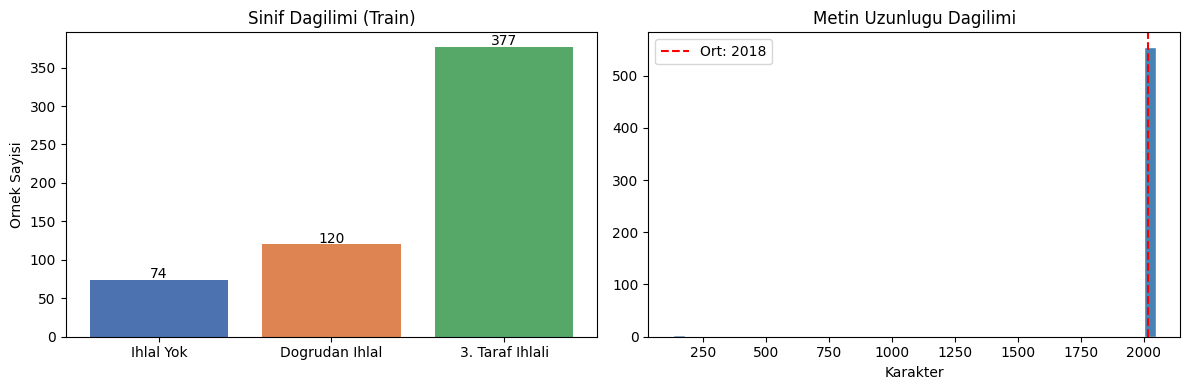

Grafik kaydedildi.


In [10]:
import pandas as pd, matplotlib.pyplot as plt, json
from collections import Counter

train_df = pd.read_csv("data/train.csv")
val_df   = pd.read_csv("data/val.csv")
test_df  = pd.read_csv("data/test.csv")

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

LABEL_NAMES = {0: "Ihlal Yok", 1: "Dogrudan Ihlal", 2: "3. Taraf Ihlali"}

# Sinif dagilimi
cnt = Counter(train_df["label"])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(
    [LABEL_NAMES[l] for l in sorted(cnt)],
    [cnt[l] for l in sorted(cnt)],
    color=["#4C72B0", "#DD8452", "#55A868"]
)
axes[0].set_title("Sinif Dagilimi (Train)")
axes[0].set_ylabel("Ornek Sayisi")
for bar, (l, n) in zip(bars, sorted(cnt.items())):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height()+2, str(n), ha='center', fontsize=10)

# Metin uzunlugu
train_df["char_len"] = train_df["text"].str.len()
axes[1].hist(train_df["char_len"], bins=40, color="steelblue", edgecolor="white")
axes[1].axvline(train_df["char_len"].mean(), color="red", linestyle="--",
                label=f"Ort: {train_df['char_len'].mean():.0f}")
axes[1].set_title("Metin Uzunlugu Dagilimi")
axes[1].set_xlabel("Karakter")
axes[1].legend()

plt.tight_layout()
os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/data_overview.png", dpi=120)
plt.show()
print("Grafik kaydedildi.")

CTI Analisti Etiket Dogrulama (Onerilir)
data_prep.py heuristik etiketleme yapiyor. CTI analisti olarak Class 1 orneklerini gozden gecirmeniz sonuclarin gucunu arttirir.

Asagidaki hucreyi calistirarak Class 1 ornekleri inceleyin ve gerekirse CSV'yi duzeltin.

In [11]:
# Class 1 (Dogrudan Ihlal) orneklerini incele
class1_df = train_df[train_df["label"] == 1].head(10)
for _, row in class1_df.iterrows():
    print(f"URL: {row.get('url', '-')}")
    print(f"Metin (ilk 200 kar): {row['text'][:200]}")
    print("-" * 60)

URL: https://krebsonsecurity.com/2017/09/canadian-man-gets-9-months-detention-for-serial-swattings-bomb-threats/
Metin (ilk 200 kar): Title: Canadian Man Gets 9 Months Detention for Serial Swattings, Bomb Threats [SEP] Content: A 19-year-old Canadian man was found guilty of making almost three dozen fraudulent calls to emergency ser
------------------------------------------------------------
URL: https://krebsonsecurity.com/2024/11/feds-charge-five-men-in-scattered-spider-roundup/
Metin (ilk 200 kar): Title: Feds Charge Five Men in ‘Scattered Spider’ Roundup [SEP] Content: Federal prosecutors in Los Angeles this week unsealed criminal charges against five men alleged to be members of a hacking grou
------------------------------------------------------------
URL: https://krebsonsecurity.com/2021/02/mexican-politician-removed-over-alleged-ties-to-romanian-atm-skimmer-gang/
Metin (ilk 200 kar): Title: Mexican Politician Removed Over Alleged Ties to Romanian ATM Skimmer Gang [SEP] Conten

4. Model Konfigurasyonu

In [12]:
MODELS = {
    "smollm2"  : "HuggingFaceTB/SmolLM2-360M",
    "tinyllama": "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    "qwen"     : "Qwen/Qwen2.5-1.5B",
    "gemma"    : "google/gemma-4-e2b-it",  # HF erisim izni gerektirir
}

# En az 3 model calistirin (benchmark protokolu)
SELECTED_MODELS = ["smollm2", "tinyllama", "qwen"]  # "gemma" eklenebilir
QUANTIZE        = {"qwen", "gemma"}                   # bu modeller 4-bit

print("Secili modeller:")
for k in SELECTED_MODELS:
    q = "(QLoRA 4-bit)" if k in QUANTIZE else "(LoRA FP16)"
    print(f"  {k:12s} {q}  ->  {MODELS[k]}")

Secili modeller:
  smollm2      (LoRA FP16)  ->  HuggingFaceTB/SmolLM2-360M
  tinyllama    (LoRA FP16)  ->  TinyLlama/TinyLlama-1.1B-Chat-v1.0
  qwen         (QLoRA 4-bit)  ->  Qwen/Qwen2.5-1.5B


5. Zero-Shot Baseline

In [13]:
import csv, torch, time
from transformers import pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report

ZERO_SHOT_MODEL = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
LABEL_NAMES_LIST = ["Ihlal Yok", "Dogrudan Ihlal", "3. Taraf Ihlali"]

PROMPT = (
    "Classify the following cybersecurity article:\n"
    "0 = No breach (general news)\n"
    "1 = Direct breach (organization directly attacked)\n"
    "2 = Third-party breach (vendor/supplier/partner involved)\n\n"
    "Article:\n{text}\n\n"
    "Answer with only the number (0, 1, or 2):"
)

print(f"Zero-shot modeli yukleniyor: {ZERO_SHOT_MODEL}")
gen = pipeline("text-generation", model=ZERO_SHOT_MODEL,
               device_map="auto", max_new_tokens=5, torch_dtype=torch.float16)

def load_csv_test(path):
    texts, labels = [], []
    with open(path) as f:
        for row in csv.DictReader(f):
            texts.append(row["text"]); labels.append(int(row["label"]))
    return texts, labels

texts, labels = load_csv_test("data/test.csv")
texts_s, labels_s = texts[:50], labels[:50]  # ilk 50 ornek (hiz icin)

preds, t0 = [], time.time()
for text in texts_s:
    out    = gen(PROMPT.format(text=text[:700]))[0]["generated_text"]
    answer = out.split("Answer with only")[-1].strip()
    digits = [c for c in answer if c in "012"]
    preds.append(int(digits[0]) if digits else 0)

elapsed = (time.time() - t0) * 1000 / len(texts_s)

acc = accuracy_score(labels_s, preds)
mf1 = f1_score(labels_s, preds, average="macro", zero_division=0)
wf1 = f1_score(labels_s, preds, average="weighted", zero_division=0)

print(f"\nZero-Shot Sonuclari (n=50):")
print(f"  Accuracy      : {acc:.4f}")
print(f"  Macro-F1      : {mf1:.4f}")
print(f"  Weighted-F1   : {wf1:.4f}")
print(f"  Inf (ms/ornek): {elapsed:.1f}")
print("\n" + classification_report(labels_s, preds, target_names=LABEL_NAMES_LIST, zero_division=0))

zero_shot_results = {
    "model": ZERO_SHOT_MODEL + " (zero-shot)",
    "accuracy": acc, "macro_f1": mf1, "weighted_f1": wf1,
    "inference_ms_per_sample": elapsed,
}

Zero-shot modeli yukleniyor: TinyLlama/TinyLlama-1.1B-Chat-v1.0


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



Zero-Shot Sonuclari (n=50):
  Accuracy      : 0.1600
  Macro-F1      : 0.0920
  Weighted-F1   : 0.0441
  Inf (ms/ornek): 172.5

                 precision    recall  f1-score   support

      Ihlal Yok       0.16      1.00      0.28         8
 Dogrudan Ihlal       0.00      0.00      0.00        10
3. Taraf Ihlali       0.00      0.00      0.00        32

       accuracy                           0.16        50
      macro avg       0.05      0.33      0.09        50
   weighted avg       0.03      0.16      0.04        50



In [17]:
!pip install -U bitsandbytes triton

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.2 MB/s eta 0:00:00
  Attempting uninstall: bitsandbytes
    Found existing installation: bitsandbytes 0.43.3
    Uninstalling bitsandbytes-0.43.3:
      Successfully uninstalled bitsandbytes-0.43.3


6. Fine-Tuning

In [18]:
import subprocess, os

os.makedirs("outputs", exist_ok=True)

for model_key in SELECTED_MODELS:
    q_flag = "--quantize" if model_key in QUANTIZE else ""
    cmd = (
        f"python train.py --model {model_key} {q_flag} "
        f"--epochs 5 --batch_size 8 --lr 2e-4 --lora_r 16 --lora_alpha 32"
    )
    print(f"\n{'='*65}")
    print(f"Basliyor: {model_key}")
    print(f"Komut  : {cmd}")

    # Hatalari yakalamak icin capture_output ve text eklendi
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)

    if result.returncode != 0:
        print(f"HATA: {model_key} basarisiz!")
        print(f"--- HATA DETAYI ---\n{result.stderr}\n-------------------")
    else:
        print(f"Tamamlandi: {model_key}")
        # Drive'a ara kayit
        import shutil, datetime
        backup = f"/content/drive/MyDrive/third_party_breach_results/model_{model_key}_{datetime.datetime.now().strftime('%H%M')}"
        shutil.copytree(f"outputs/{model_key}", backup, dirs_exist_ok=True)
        print(f"Drive'a kaydedildi: {backup}")

print("\nTum egitimler tamamlandi.")


Basliyor: smollm2
Komut  : python train.py --model smollm2  --epochs 5 --batch_size 8 --lr 2e-4 --lora_r 16 --lora_alpha 32
Tamamlandi: smollm2
Drive'a kaydedildi: /content/drive/MyDrive/third_party_breach_results/model_smollm2_1907

Basliyor: tinyllama
Komut  : python train.py --model tinyllama  --epochs 5 --batch_size 8 --lr 2e-4 --lora_r 16 --lora_alpha 32
HATA: tinyllama basarisiz!
--- HATA DETAYI ---
Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at TinyLlama/TinyLlama-1.1B-Chat-v1.0 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:488: Futur

In [19]:
import subprocess, os, shutil, datetime

# Sadece tinyllama'yı eğitiyoruz
SELECTED_MODELS = ["tinyllama"]
# Quantization şart (4-bit)
QUANTIZE = {"tinyllama"}

os.makedirs("outputs", exist_ok=True)

for model_key in SELECTED_MODELS:
    q_flag = "--quantize" if model_key in QUANTIZE else ""

    # batch_size=4 olarak düşürüldü
    cmd = (
        f"python train.py --model {model_key} {q_flag} "
        f"--epochs 5 --batch_size 4 --lr 2e-4 --lora_r 16 --lora_alpha 32"
    )

    print(f"\n{'='*65}")
    print(f"Basliyor: {model_key}")
    print(f"Komut   : {cmd}")

    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)

    if result.returncode != 0:
        print(f"HATA: {model_key} basarisiz!")
        print(f"--- HATA DETAYI ---\n{result.stderr}\n-------------------")
    else:
        print(f"Tamamlandi: {model_key}")
        backup = f"/content/drive/MyDrive/third_party_breach_results/model_{model_key}_{datetime.datetime.now().strftime('%H%M')}"
        shutil.copytree(f"outputs/{model_key}", backup, dirs_exist_ok=True)
        print(f"Drive'a kaydedildi: {backup}")

print("\nTinyLlama egitimi tamamlandi.")


Basliyor: tinyllama
Komut   : python train.py --model tinyllama --quantize --epochs 5 --batch_size 4 --lr 2e-4 --lora_r 16 --lora_alpha 32
Tamamlandi: tinyllama
Drive'a kaydedildi: /content/drive/MyDrive/third_party_breach_results/model_tinyllama_1953

TinyLlama egitimi tamamlandi.


7. Test Seti Degerlendirme & Karsilastirma

In [31]:
import os

# "outputs" klasorunun icindeki tum alt klasorleri bul (smollm2, qwen, tinyllama vb.)
model_dirs = [f"outputs/{d}" for d in os.listdir("outputs") if os.path.isdir(f"outputs/{d}")]

print("Degerlendirilecek:", model_dirs)

# Klasor yollarini boslukla birlestir
dirs_str = " ".join(model_dirs)

# Tum modelleri evaluate.py'ye gonder (sadece test setinde degerlendirme yapar)
!python evaluate.py --compare {dirs_str} --out_dir outputs

Degerlendirilecek: ['outputs/qwen', 'outputs/smollm2', 'outputs/tinyllama']

[Fine-tuned] outputs/qwen
Some weights of Qwen2ForSequenceClassification were not initialized from the model checkpoint at Qwen/Qwen2.5-1.5B and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
We detected that you are passing `past_key_values` as a tuple and this is deprecated and will be removed in v4.43. Please use an appropriate `Cache` class (https://huggingface.co/docs/transformers/v4.41.3/en/internal/generation_utils#transformers.Cache)
  Accuracy        : 0.3108
  Macro-F1        : 0.2590
  Weighted-F1     : 0.3357
  Macro-Precision : 0.3160
  Macro-Recall    : 0.2972
  inference_ms_per_sample  : 295.05 ms/sample
  gpu_memory_gb            : 10.12 GB
  disk_size_mb             : 1131.8 MB

                 precision    recall  f1-score   support

      Ihlal Yok       0.09      0.10      0.10        10

In [33]:
import json, pandas as pd

with open("outputs/comparison_results.json") as f:
    results = json.load(f)

# Zero-shot'u da ekle
if 'zero_shot_results' in dir():
    results_with_zs = [zero_shot_results] + results
else:
    results_with_zs = results

df = pd.DataFrame([{
    "Model"       : r.get("name", r.get("model", "Bilinmeyen")).split("/")[-1][:22],
    "Accuracy"    : r.get("accuracy", "-"),
    "Macro-F1"    : r.get("macro_f1", "-"),
    "Weighted-F1" : r.get("weighted_f1", "-"),
    "Macro-Prec"  : r.get("macro_precision", "-"),
    "Macro-Rec"   : r.get("macro_recall", "-"),
    "ms/ornek"    : r.get("inference_ms_per_sample", "-"),
    "Disk MB"     : r.get("disk_size_mb", "-"),
} for r in results_with_zs])

print("\n=== FINAL SONUCLARI ===")
print(df.to_string(index=False))
df.to_csv("outputs/final_results.csv", index=False)
print("\nKaydedildi: outputs/final_results.csv")


=== FINAL SONUCLARI ===
                 Model  Accuracy  Macro-F1  Weighted-F1 Macro-Prec Macro-Rec   ms/ornek Disk MB
TinyLlama-1.1B-Chat-v1    0.1600  0.091954     0.044138          -         - 172.536311       -
          Qwen2.5-1.5B    0.3919  0.326300     0.415600      0.487    0.3875 291.010000  1131.8
          SmolLM2-360M    0.7432  0.580400     0.741700     0.5884    0.6014  97.070000   534.0
TinyLlama-1.1B-Chat-v1    0.2432  0.272800     0.219900     0.3767    0.3431 149.210000   630.0

Kaydedildi: outputs/final_results.csv


In [35]:
import json, os, torch, gc
from evaluate import evaluate_finetuned, plot_confusion

model_dirs = [f"outputs/{d}" for d in os.listdir("outputs") if os.path.isdir(f"outputs/{d}")]
all_results = []

for m_dir in model_dirs:
    try:
        # batch_size=2 ile VRAM'i koruyarak degerlendir
        res = evaluate_finetuned(m_dir, "data/test.csv", batch_size=2)
        plot_confusion(res, "outputs")
        all_results.append(res)
    except Exception as e:
        print(f"HATA ({m_dir}): {e}")
    finally:
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

# 3 modelin sonucunu da JSON'a kaydet
with open("outputs/comparison_results.json", "w") as f:
    json.dump(all_results, f, indent=2)
print("Degerlendirmeler bitti, JSON dosyasi 3 modelle guncellendi!")


[Fine-tuned] outputs/qwen


Some weights of Qwen2ForSequenceClassification were not initialized from the model checkpoint at Qwen/Qwen2.5-1.5B and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Accuracy        : 0.2973
  Macro-F1        : 0.2823
  Weighted-F1     : 0.3061
  Macro-Precision : 0.3496
  Macro-Recall    : 0.3569
  inference_ms_per_sample  : 278.88 ms/sample
  gpu_memory_gb            : 12.18 GB
  disk_size_mb             : 1131.8 MB

                 precision    recall  f1-score   support

      Ihlal Yok       0.12      0.30      0.18        10
 Dogrudan Ihlal       0.26      0.56      0.35        16
3. Taraf Ihlali       0.67      0.21      0.32        48

       accuracy                           0.30        74
      macro avg       0.35      0.36      0.28        74
   weighted avg       0.50      0.30      0.31        74

Confusion Matrix:
  (rows=true, cols=pred) | Ihlal Yok | Dogrudan Ihlal | 3. Taraf Ihlali
[[ 3  6  1]
 [ 3  9  4]
 [18 20 10]]
Confusion matrix kaydedildi: outputs/cm_Qwen2.5-1.5B.png

[Fine-tuned] outputs/smollm2


Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at HuggingFaceTB/SmolLM2-360M and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Accuracy        : 0.1622
  Macro-F1        : 0.1814
  Weighted-F1     : 0.1264
  Macro-Precision : 0.2099
  Macro-Recall    : 0.2597
  inference_ms_per_sample  : 86.45 ms/sample
  gpu_memory_gb            : 3.67 GB
  disk_size_mb             : 534.0 MB

                 precision    recall  f1-score   support

      Ihlal Yok       0.25      0.30      0.27        10
 Dogrudan Ihlal       0.13      0.44      0.20        16
3. Taraf Ihlali       0.25      0.04      0.07        48

       accuracy                           0.16        74
      macro avg       0.21      0.26      0.18        74
   weighted avg       0.22      0.16      0.13        74

Confusion Matrix:
  (rows=true, cols=pred) | Ihlal Yok | Dogrudan Ihlal | 3. Taraf Ihlali
[[ 3  4  3]
 [ 6  7  3]
 [ 3 43  2]]
Confusion matrix kaydedildi: outputs/cm_SmolLM2-360M.png

[Fine-tuned] outputs/tinyllama


Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at TinyLlama/TinyLlama-1.1B-Chat-v1.0 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Accuracy        : 0.1351
  Macro-F1        : 0.1622
  Weighted-F1     : 0.1109
  Macro-Precision : 0.1918
  Macro-Recall    : 0.2444
  inference_ms_per_sample  : 152.99 ms/sample
  gpu_memory_gb            : 6.17 GB
  disk_size_mb             : 630.0 MB

                 precision    recall  f1-score   support

      Ihlal Yok       0.08      0.40      0.13        10
 Dogrudan Ihlal       0.33      0.31      0.32        16
3. Taraf Ihlali       0.17      0.02      0.04        48

       accuracy                           0.14        74
      macro avg       0.19      0.24      0.16        74
   weighted avg       0.19      0.14      0.11        74

Confusion Matrix:
  (rows=true, cols=pred) | Ihlal Yok | Dogrudan Ihlal | 3. Taraf Ihlali
[[ 4  3  3]
 [ 9  5  2]
 [40  7  1]]
Confusion matrix kaydedildi: outputs/cm_TinyLlama-1.1B-Chat-.png
Degerlendirmeler bitti, JSON dosyasi 3 modelle guncellendi!


In [36]:
import json, pandas as pd

with open("outputs/comparison_results.json") as f:
    results = json.load(f)

if 'zero_shot_results' in dir():
    results_with_zs = [zero_shot_results] + results
else:
    results_with_zs = results

df = pd.DataFrame([{
    "Model"       : r.get("name", r.get("model", "Bilinmeyen")).split("/")[-1][:22],
    "Accuracy"    : r.get("accuracy", "-"),
    "Macro-F1"    : r.get("macro_f1", "-"),
    "Weighted-F1" : r.get("weighted_f1", "-"),
    "Macro-Prec"  : r.get("macro_precision", "-"),
    "Macro-Rec"   : r.get("macro_recall", "-"),
    "ms/ornek"    : r.get("inference_ms_per_sample", "-"),
    "Disk MB"     : r.get("disk_size_mb", "-"),
} for r in results_with_zs])

print("\n=== FINAL SONUCLARI ===")
print(df.to_string(index=False))
df.to_csv("outputs/final_results.csv", index=False)


=== FINAL SONUCLARI ===
                 Model  Accuracy  Macro-F1  Weighted-F1 Macro-Prec Macro-Rec   ms/ornek Disk MB
TinyLlama-1.1B-Chat-v1    0.1600  0.091954     0.044138          -         - 172.536311       -
          Qwen2.5-1.5B    0.2973  0.282300     0.306100     0.3496    0.3569 278.880000  1131.8
          SmolLM2-360M    0.1622  0.181400     0.126400     0.2099    0.2597  86.450000   534.0
TinyLlama-1.1B-Chat-v1    0.1351  0.162200     0.110900     0.1918    0.2444 152.990000   630.0



--- outputs/model_comparison.png ---


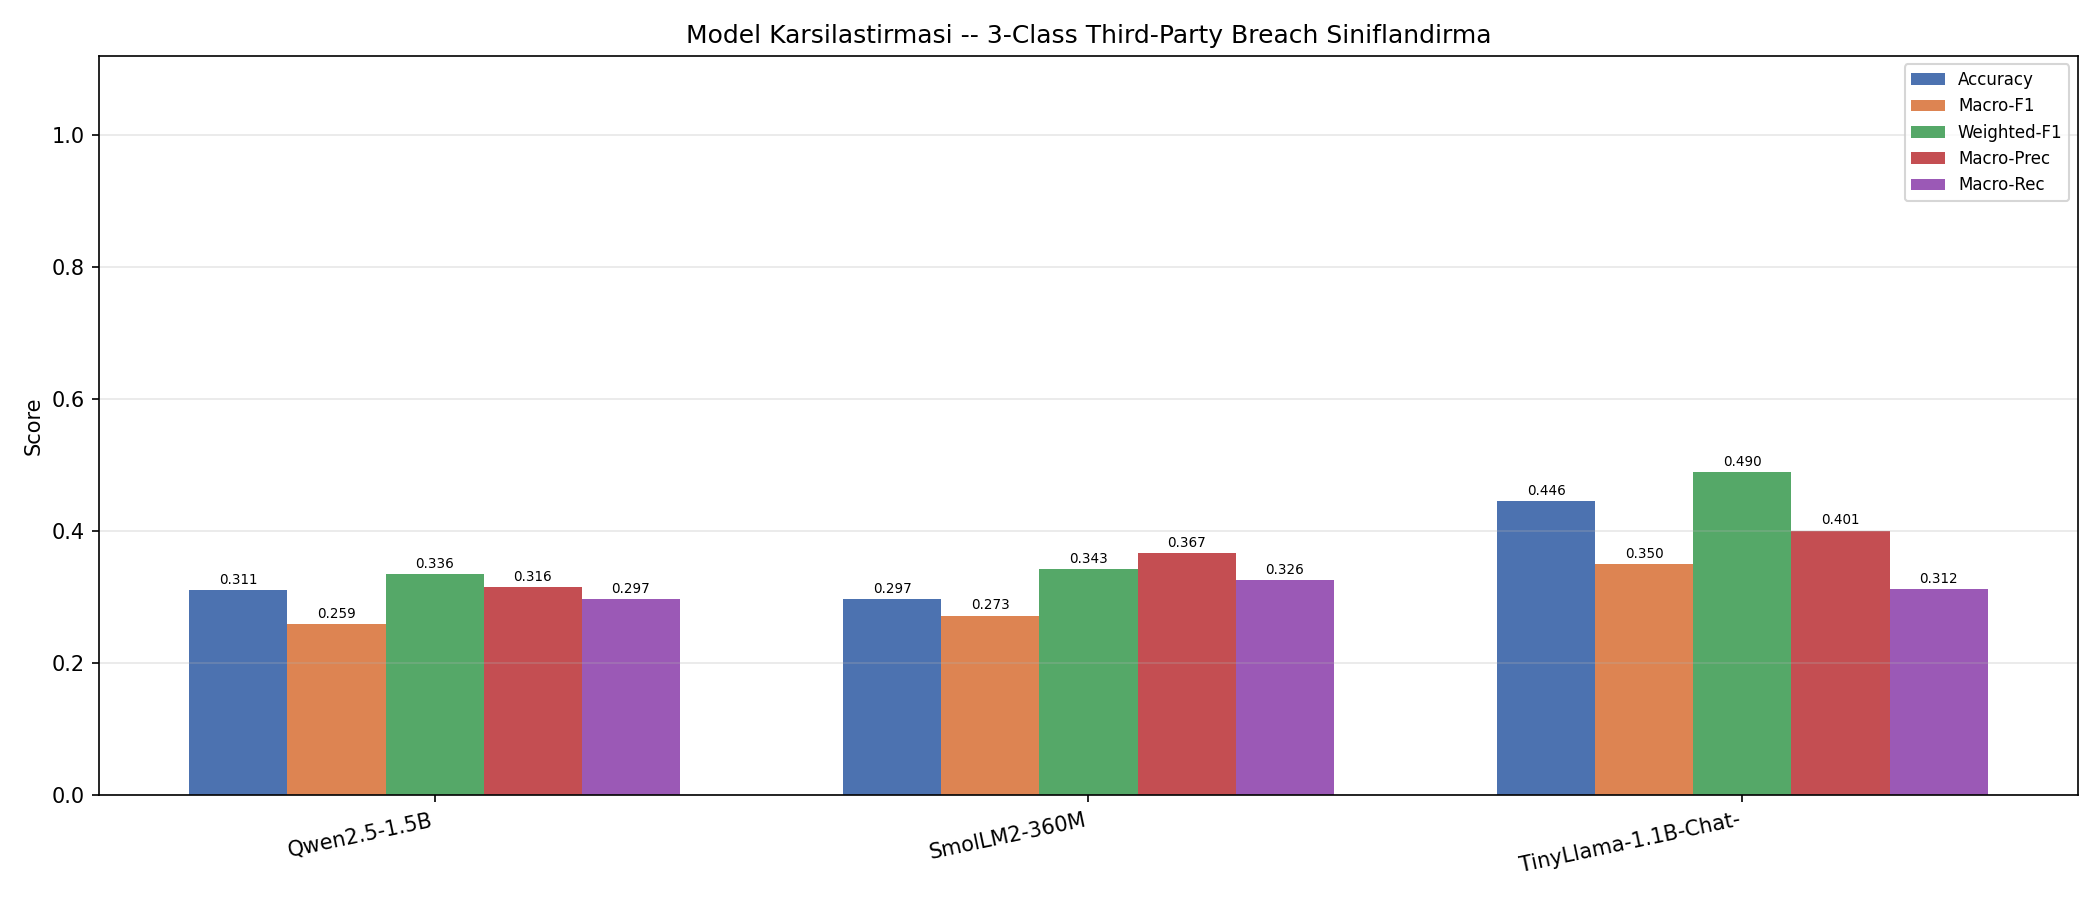


--- outputs/efficiency_plot.png ---


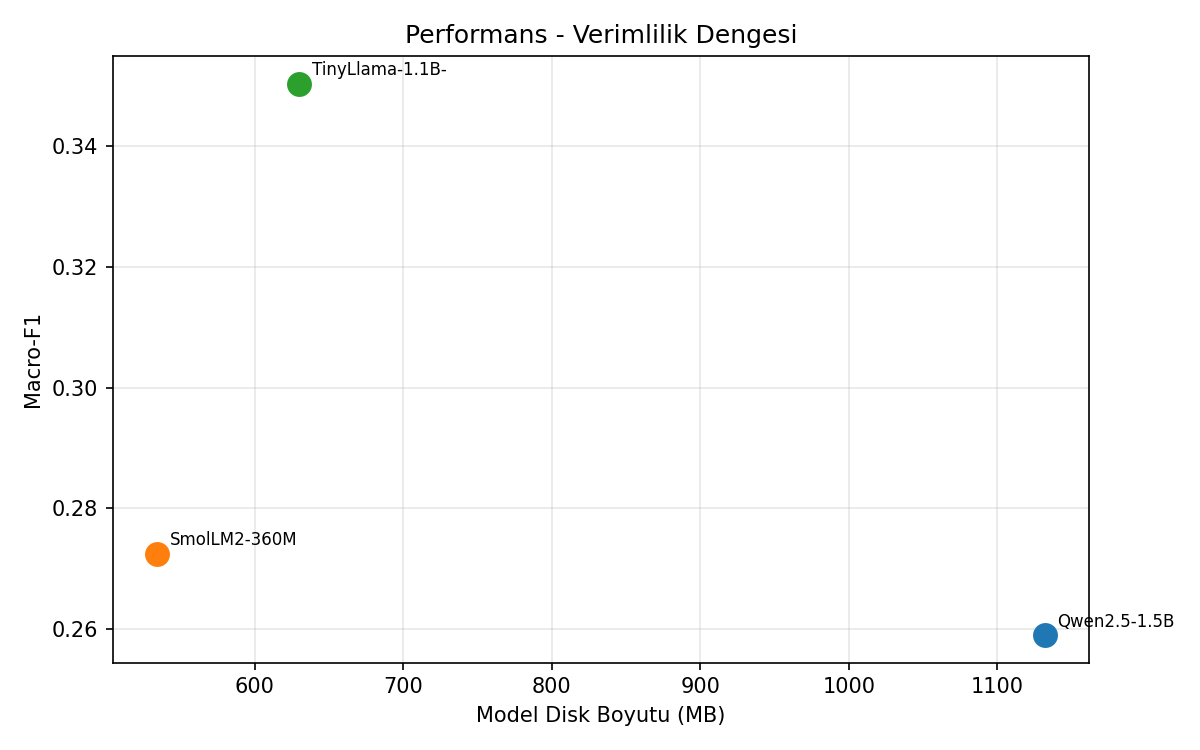


--- outputs/data_overview.png ---


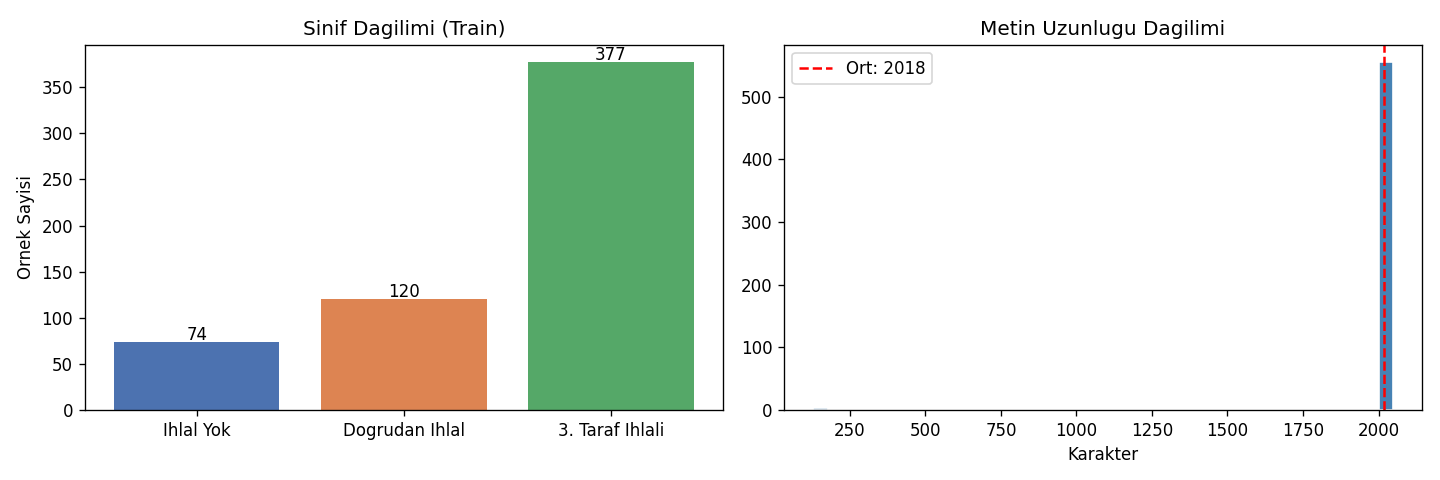

In [37]:
import os
from IPython.display import Image, display

grafikler = [
    "outputs/model_comparison.png",
    "outputs/efficiency_plot.png",
    "outputs/data_overview.png"
]

for img in grafikler:
    if os.path.exists(img):
        print(f"\n--- {img} ---")
        display(Image(filename=img))
    else:
        print(f"\nUyarı: Dosya bulunamadı -> {img}")

8. Hata Analizi (CTI Analisti Perspektifi)

In [40]:
# En iyi modelde hata analizi
BEST_MODEL_DIR = "outputs/tinyllama"  # sonuclara gore degistirin

if os.path.exists(BEST_MODEL_DIR):
    !python evaluate.py --model_dir {BEST_MODEL_DIR} --error_analysis --test_csv data/test.csv --out_dir outputs

    with open("outputs/error_analysis.json") as f:
        errors = json.load(f)

    print(f"\nIlk 5 yanlis siniflandirma (CTI analisti gozuyle):")
    for e in errors[:5]:
        print(f"  [{e['idx']}] Gercek={e['true_name']} | Tahmin={e['pred_name']} | Guven={e['confidence']}")
        print(f"       {e['text_snippet'][:250]}")
        print()


[Fine-tuned] outputs/tinyllama
Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at TinyLlama/TinyLlama-1.1B-Chat-v1.0 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
We detected that you are passing `past_key_values` as a tuple and this is deprecated and will be removed in v4.43. Please use an appropriate `Cache` class (https://huggingface.co/docs/transformers/v4.41.3/en/internal/generation_utils#transformers.Cache)
  Accuracy        : 0.5676
  Macro-F1        : 0.4133
  Weighted-F1     : 0.5718
  Macro-Precision : 0.4242
  Macro-Recall    : 0.4514
  inference_ms_per_sample  : 166.32 ms/sample
  gpu_memory_gb            : 4.32 GB
  disk_size_mb             : 630.0 MB

                 precision    recall  f1-score   support

      Ihlal Yok       0.23      0.50      0.31        10
 Dogrudan Ihlal       0.25      0.12      0.17        1

9. Sonuclari Drive'a Kaydet

In [39]:
import shutil, datetime

ts       = datetime.datetime.now().strftime("%Y%m%d_%H%M")
save_dir = f"/content/drive/MyDrive/third_party_breach_results_{ts}"
os.makedirs(save_dir, exist_ok=True)

for fname in [
    "outputs/final_results.csv",
    "outputs/comparison_results.json",
    "outputs/model_comparison.png",
    "outputs/efficiency_plot.png",
    "outputs/data_overview.png",
    "outputs/error_analysis.json",
    "data/dataset_stats.json",
]:
    if os.path.exists(fname):
        shutil.copy(fname, save_dir)

print(f"Sonuclar Drive'a kaydedildi:\n  {save_dir}")

Sonuclar Drive'a kaydedildi:
  /content/drive/MyDrive/third_party_breach_results_20260531_2030
